# Week4복습과제_신아영

**4주차 논문(ViT) 관련 코드 실습**

- 교재: *파이토치 트랜스포머를 활용한 자연어 처리와 컴퓨터비전 심층학습*
- 범위: 10장 中 ViT 모델 실습 (p.609~624)
- 내용: 교재의 예제 10.1 ~ 10.9를 따라가며 FashionMNIST 데이터 준비 → 전처리 → 데이터로더 → 사전 학습된 ViT 불러오기 → 패치 임베딩 확인 → 하이퍼파라미터/평가지표 설정 → Trainer로 미세조정 → 혼동 행렬로 성능 평가까지 직접 실행한다.

---

### 참고 — 교재 코드에서 바뀐 부분

실행 환경(Colab · Python 3.13 · transformers 5.x)이 교재 집필 당시보다 최신이라, `TrainingArguments`·`Trainer`의 인자 이름이 몇 개 바뀌었다. 그 세 군데만 최신 버전에 맞게 고쳤고 나머지는 교재와 동일하다.

- `evaluation_strategy` → `eval_strategy` (이름 변경)
- `logging_dir` → 제거 (최신 버전에서 없어진 인자)
- `Trainer(tokenizer=...)` → `Trainer(processing_class=...)` (이름 변경)

또 FashionMNIST는 맨 아래 데이터 준비 셀에서 Zalando 공식 GitHub 저장소의 원본 파일을 받아 쓴다(MD5 체크섬이 torchvision 검증값과 일치하는 것을 확인).

### [환경 설정] FashionMNIST 데이터 준비
교재는 `datasets.FashionMNIST(..., download=True)`로 데이터를 받지만, 이 실습 환경은 torchvision 기본 다운로드 서버 접속이 막혀 있다. FashionMNIST는 공개 데이터라 제작사인 Zalando의 공식 GitHub 저장소에서 동일한 원본 파일을 받아 torchvision이 기대하는 폴더 구조에 넣어준다. (받은 파일의 MD5가 torchvision이 검증하는 값과 일치하는 것을 확인함)

In [ ]:
!pip install -q transformers evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.8 MB/s eta 0:00:00


In [ ]:
import os, urllib.request, hashlib

base = "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/"
raw_dir = "./datasets/FashionMNIST/raw"
os.makedirs(raw_dir, exist_ok=True)

files = {
    "train-images-idx3-ubyte.gz": "8d4fb7e6c68d591d4c3dfef9ec88bf0d",
    "train-labels-idx1-ubyte.gz": "25c81989df183df01b3e8a0aad5dffbe",
    "t10k-images-idx3-ubyte.gz":  "bef4ecab320f06d8554ea6380940ec79",
    "t10k-labels-idx1-ubyte.gz":  "bb300cfdad3c16e7a12a480ee83cd310",
}

for fname, md5 in files.items():
    dst = os.path.join(raw_dir, fname)
    req = urllib.request.Request(base + fname, headers={"User-Agent": "Mozilla/5.0"})
    data = urllib.request.urlopen(req, timeout=120).read()
    with open(dst, "wb") as f:
        f.write(data)
    assert hashlib.md5(data).hexdigest() == md5, f"MD5 mismatch: {fname}"
    print(f"{fname}: {len(data):,} bytes, MD5 확인 완료")

print("FashionMNIST 원본 파일 4개 준비 완료")

train-images-idx3-ubyte.gz: 26,421,880 bytes, MD5 확인 완료
train-labels-idx1-ubyte.gz: 29,515 bytes, MD5 확인 완료
t10k-images-idx3-ubyte.gz: 4,422,102 bytes, MD5 확인 완료
t10k-labels-idx1-ubyte.gz: 5,148 bytes, MD5 확인 완료
FashionMNIST 원본 파일 4개 준비 완료


## 예제 10.1 FashionMNIST 다운로드
간단한 실습을 위해 학습 데이터를 10,000개, 테스트 데이터를 1,000개로 샘플링한다. `subset_sampler`는 클래스별로 `max_len`개씩만 뽑아 균등하게 서브셋을 구성하는 함수다. (위에서 데이터를 미리 받아놨으므로 `download=True`여도 네트워크 접속 없이 로컬 파일을 그대로 사용한다.)

In [ ]:
from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets


def subset_sampler(dataset, classes, max_len):
    target_idx = defaultdict(list)
    for idx, label in enumerate(dataset.train_labels):
        target_idx[int(label)].append(idx)

    indices = list(
        chain.from_iterable(
            [target_idx[idx][:max_len] for idx in range(len(classes))]
        )
    )
    return Subset(dataset, indices)


train_dataset = datasets.FashionMNIST(root="./datasets", download=True, train=True)
test_dataset = datasets.FashionMNIST(root="./datasets", download=True, train=False)

classes = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

print(classes)
print(class_to_idx)

subset_train_dataset = subset_sampler(
    dataset=train_dataset, classes=train_dataset.classes, max_len=1000
)
subset_test_dataset = subset_sampler(
    dataset=test_dataset, classes=test_dataset.classes, max_len=100
)

print(f"Training Data Size : {len(subset_train_dataset)}")
print(f"Testing Data Size : {len(subset_test_dataset)}")
print(train_dataset[0])

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}


/usr/local/lib/python3.13/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")


Training Data Size : 10000
Testing Data Size : 1000
(<PIL.Image.Image image mode=L size=28x28 at 0x7A282C09A5D0>, 9)


출력 결과를 보면 FashionMNIST는 10개 클래스(T-shirt/top ~ Ankle boot)로 구성되고, `subset_sampler`로 클래스마다 1,000개/100개씩 뽑아 학습 10,000개·테스트 1,000개의 서브셋이 만들어진 것을 확인할 수 있다. 개별 데이터는 28×28 흑백 PIL 이미지와 클래스 번호로 이루어져 있다.

## 예제 10.2 이미지 전처리
이미지 프로세서 클래스(`AutoImageProcessor`)는 사전 학습된 ViT 모델에 맞춰 전처리를 수행한다. ViT 모델은 `PIL.Image`가 아니라 `Tensor`를 입력으로 받으므로, 크기를 224×224로 맞추고(`Resize`), FashionMNIST는 흑백 1채널이라 `transforms.Lambda`로 같은 값을 3번 복제해 3채널로 만든 뒤(`torch.cat([x, x, x], 0)`), 정규화(`Normalize`)를 적용한다.

In [ ]:
import torch
from torchvision import transforms
from transformers import AutoImageProcessor

image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path="google/vit-base-patch16-224-in21k"
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(
            size=(
                image_processor.size["height"],
                image_processor.size["width"]
            )
        ),
        transforms.Lambda(
            lambda x: torch.cat([x, x, x], 0)
        ),
        transforms.Normalize(
            mean=image_processor.image_mean,
            std=image_processor.image_std
        )
    ]
)

print(f"size : {image_processor.size}")
print(f"mean : {image_processor.image_mean}")
print(f"std : {image_processor.image_std}")

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

size : SizeDict(height=224, width=224, longest_edge=None, shortest_edge=None, max_height=None, max_width=None, min_pixels=None, max_pixels=None)
mean : (0.5, 0.5, 0.5)
std : (0.5, 0.5, 0.5)


## 예제 10.3 ViT 데이터로더 적용
ViT 모델의 입력은 `{"pixel_values": ..., "labels": ...}` 형태라서, 데이터로더에 집합 함수(`collate_fn`)를 적용해 미니 배치를 이 구조로 묶어준다. `collator`는 배치 안 이미지들에 위 `transform`을 적용해 `(배치, 채널, 높이, 너비)` 형태의 `pixel_values`와 클래스 번호 `labels`를 반환한다.

In [ ]:
from torch.utils.data import DataLoader


def collator(data, transform):
    images, labels = zip(*data)
    pixel_values = torch.stack([transform(image) for image in images])
    labels = torch.tensor([label for label in labels])
    return {"pixel_values": pixel_values, "labels": labels}


train_dataloader = DataLoader(
    subset_train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=lambda x: collator(x, transform),
    drop_last=True
)
valid_dataloader = DataLoader(
    subset_test_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=lambda x: collator(x, transform),
    drop_last=True
)

batch = next(iter(train_dataloader))
for key, value in batch.items():
    print(f"{key} : {value.shape}")

pixel_values : torch.Size([32, 3, 224, 224])
labels : torch.Size([32])


## 예제 10.4 사전 학습된 ViT 모델
허깅페이스의 `ViTForImageClassification`으로 사전 학습된 ViT를 불러온다. 이 모델은 ImageNet-21k(약 1,400만 장, 21,841개 클래스)로 학습돼 있어서, 우리 데이터(10개 클래스)에 맞게 미세조정이 필요하다. `num_labels`, `id2label`, `label2id`로 분류 헤드를 새 데이터에 맞추고, `ignore_mismatched_sizes=True`로 기존 분류 헤드와 크기가 달라도 덮어쓰도록 한다.

In [ ]:
from transformers import ViTForImageClassification

model = ViTForImageClassification.from_pretrained(
    pretrained_model_name_or_path="google/vit-base-patch16-224-in21k",
    num_labels=len(classes),
    id2label={idx: label for label, idx in class_to_idx.items()},
    label2id=class_to_idx,
    ignore_mismatched_sizes=True
)

print(model.classifier)

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Linear(in_features=768, out_features=10, bias=True)


## 예제 10.5 패치 임베딩 확인
ViT는 7장의 트랜스포머와 달리, 입력 이미지를 16×16 패치로 잘라 패치마다 특성을 뽑는 **패치 임베딩**이 앞에 붙는다. 패치 임베딩은 16×16 커널·16 간격의 합성곱(`Conv2d`)으로 구현되는데, 224×224 이미지면 (224/16)² = 14×14 = 196개의 패치가 만들어진다. 그 뒤 패치 앞에 `[CLS]` 토큰이 하나 붙어 총 197개의 벡터가 된다.

In [ ]:
print(model.vit.embeddings)

batch = next(iter(train_dataloader))
print("image shape :", batch["pixel_values"].shape)
print("patch embeddings shape :",
    model.vit.embeddings.patch_embeddings(batch["pixel_values"]).shape
)
print("[CLS] + patch embeddings shape :",
    model.vit.embeddings(batch["pixel_values"]).shape
)

ViTEmbeddings(
  (patch_embeddings): ViTPatchEmbeddings(
    (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  )
  (dropout): Dropout(p=0.0, inplace=False)
)
image shape : torch.Size([32, 3, 224, 224])
patch embeddings shape : torch.Size([32, 196, 768])
[CLS] + patch embeddings shape : torch.Size([32, 197, 768])


## 예제 10.6 하이퍼파라미터 설정
학습 매개변수 클래스(`TrainingArguments`)는 체크포인트 저장/평가 간격, 학습률, 배치 크기, epoch 수, 가중치 감쇠 등 학습에 필요한 설정을 한곳에서 관리한다. 여기서는 학습률 1e-5, 배치 16, epoch 3, 최적 모델 선택 기준은 F1 점수로 설정했다.

In [ ]:
from transformers import TrainingArguments

args = TrainingArguments(
    output_dir="../models/ViT-FashionMNIST",
    save_strategy="epoch",
    eval_strategy="epoch",          # ← evaluation_strategy 에서 변경
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.001,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=125,              # ← logging_dir="logs" 줄은 삭제
    remove_unused_columns=False,
    seed=7
)

## 예제 10.7 메크로 평균 F1 점수
성능 평가 지표로는 **매크로 평균 F1 점수**를 쓴다. 다중 클래스이므로 모든 클래스의 F1 점수를 평균(`average="macro"`)해 전체 성능을 측정한다. 허깅페이스 평가 라이브러리(`evaluate`)로 F1 메트릭을 불러와 계산한다.

In [ ]:
import evaluate
import numpy as np


def compute_metrics(eval_pred):
    metric = evaluate.load("f1")
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    macro_f1 = metric.compute(
        predictions=predictions, references=labels, average="macro"
    )
    return macro_f1

## 예제 10.8 ViT 모델 학습
앞의 과정을 모두 모아, 훈련자 클래스(`Trainer`)로 ViT를 미세조정하는 전체 코드다. `Trainer`는 모델을 함수(`model_init`) 형태로 받고, 데이터셋과 집합 함수(`data_collator`), 평가 함수(`compute_metrics`), 토크나이저(여기서는 이미지 프로세서)를 함께 전달받아 내부에서 학습 루프를 돌린다. 설정이 끝나면 `trainer.train()`으로 학습을 시작한다.

In [ ]:
import torch
import evaluate
import numpy as np
from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets
from torchvision import transforms
from transformers import AutoImageProcessor
from transformers import ViTForImageClassification
from transformers import TrainingArguments, Trainer


def subset_sampler(dataset, classes, max_len):
    target_idx = defaultdict(list)
    for idx, label in enumerate(dataset.train_labels):
        target_idx[int(label)].append(idx)

    indices = list(
        chain.from_iterable(
            [target_idx[idx][:max_len] for idx in range(len(classes))]
        )
    )
    return Subset(dataset, indices)


def model_init(classes, class_to_idx):
    model = ViTForImageClassification.from_pretrained(
        pretrained_model_name_or_path="google/vit-base-patch16-224-in21k",
        num_labels=len(classes),
        id2label={idx: label for label, idx in class_to_idx.items()},
        label2id=class_to_idx,
    )
    return model


def collator(data, transform):
    images, labels = zip(*data)
    pixel_values = torch.stack([transform(image) for image in images])
    labels = torch.tensor([label for label in labels])
    return {"pixel_values": pixel_values, "labels": labels}


def compute_metrics(eval_pred):
    metric = evaluate.load("f1")
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    macro_f1 = metric.compute(
        predictions=predictions, references=labels, average="macro"
    )
    return macro_f1


train_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=True)
test_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=False)

classes = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

subset_train_dataset = subset_sampler(
    dataset=train_dataset, classes=train_dataset.classes, max_len=1000
)
subset_test_dataset = subset_sampler(
    dataset=test_dataset, classes=test_dataset.classes, max_len=100
)

image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path="google/vit-base-patch16-224-in21k"
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(
            size=(
                image_processor.size["height"],
                image_processor.size["width"]
            )
        ),
        transforms.Lambda(
            lambda x: torch.cat([x, x, x], 0)
        ),
        transforms.Normalize(
            mean=image_processor.image_mean,
            std=image_processor.image_std
        )
    ]
)

args = TrainingArguments(
    output_dir="../models/ViT-FashionMNIST",
    save_strategy="epoch",
    eval_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.001,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=125,
    remove_unused_columns=False,
    seed=7
)

trainer = Trainer(
    model_init=lambda x: model_init(classes, class_to_idx),
    args=args,
    train_dataset=subset_train_dataset,
    eval_dataset=subset_test_dataset,
    data_collator=lambda x: collator(x, transform),
    compute_metrics=compute_metrics,
    processing_class=image_processor,   # ← tokenizer= 에서 변경
)
trainer.train()

100%|██████████| 26.4M/26.4M [00:03<00:00, 7.49MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 167kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.11MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 7.66MB/s]
/usr/local/lib/python3.13/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['vit.layers.0.attention.q_proj.weight', 'vit.layers.0.attention.q_proj.bias', 'vit.layers.0.attention.k_proj.weight', 'vit.layers.0.attention.k_proj.bias', 'vit.layers.0.attention.v_proj.weight', 'vit.layers.0.attention.v_proj.bias', 'vit.layers.0.attention.o_proj.weight', 'vit.layers.0.attention.o_proj.bias', 'vit.layers.0.layernorm_before.weight', 'vit.layers.0.layernorm_before.bias', 'vit.layers.0.layernorm_after.weight', 'vit.layers.0.layernorm_after.bias', 'vit.layers.0.mlp.fc1.weight', 'vit.layers.0.mlp.fc1.bias', 'vit.layers.0.mlp.fc2.weight', 'vit.layers.0.mlp.fc2.bias', 'vit.layers.1.attention.q_proj.weight', 'vit.layers.1.attention.q_proj.bias', 'vit.layers.1.attention.k_proj.weight', 'vit.layers.1.attention.k_proj.bias', 'vit.layers.1.attention.v_proj.weight', 'vit.layers.1.attention.v_proj.bias', 'vit.layers.1.attention.o_proj.weight', 'vit.layers.1.attention.o_proj.bias', 'vit.layers.1.layernorm_before

TrainOutput(global_step=1875, training_loss=0.7132407409667969, metrics={'train_runtime': 1118.4078, 'train_samples_per_second': 26.824, 'train_steps_per_second': 1.676, 'total_flos': 2.32492637712384e+18, 'train_loss': 0.7132407409667969, 'epoch': 3.0})

**교재 학습 결과 (표 10.3) — 비교용**

교재가 보고한 결과는 아래와 같다. 위에서 직접 돌린 결과와 비교해보면 비슷한 수준으로 재현되는지 확인할 수 있다.

| Epoch | Training Loss | Validation Loss | F1-Score |
|:---:|:---:|:---:|:---:|
| 1 | 0.7062 | 0.6377 | 0.8905 |
| 2 | 0.4954 | 0.4781 | 0.9166 |
| 3 | 0.4078 | 0.4357 | 0.9231 |

epoch이 진행될수록 손실이 줄고 F1이 오르는 흐름이다.

## 예제 10.9 ViT 모델 성능 평가
학습한 모델을 테스트 데이터로 평가하고, 혼동 행렬(Confusion Matrix)로 클래스별 성능을 확인한다. `trainer.predict`로 예측을 얻고, `sklearn`의 `confusion_matrix`·`ConfusionMatrixDisplay`로 시각화한다.

PredictionOutput(predictions=array([[ 3.002603  , -0.5565888 , -0.435662  , ..., -0.46110827,
        -0.51543623, -0.38755268],
       [ 1.6204133 , -0.6574332 , -0.28072077, ..., -0.78203666,
        -0.65929383, -0.60191524],
       [ 2.934516  , -0.5411857 , -0.40410835, ..., -0.3766476 ,
        -0.54536533, -0.44463435],
       ...,
       [-0.4881711 , -0.70149076, -0.5734923 , ...,  0.42078197,
         0.01644613,  3.0136979 ],
       [-0.27329472, -0.6030811 , -0.6087805 , ...,  0.11858723,
        -0.4585756 ,  3.2244616 ],
       [-0.3189185 , -0.55879265, -0.5714179 , ..., -0.21744932,
        -0.28943914,  3.211238  ]], dtype=float32), label_ids=array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

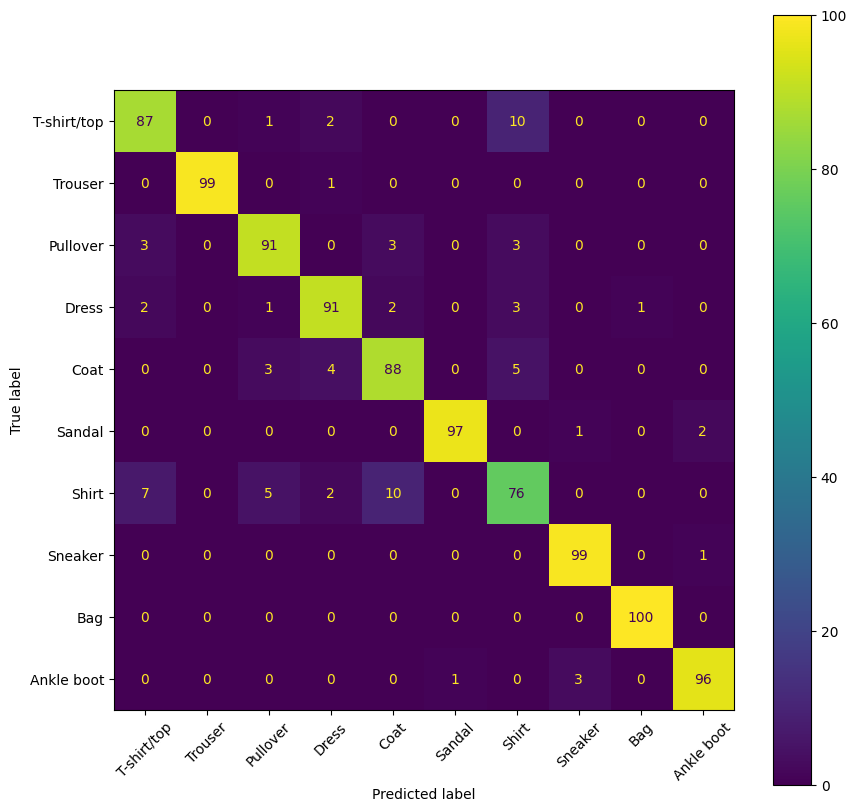

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

outputs = trainer.predict(subset_test_dataset)
print(outputs)

y_true = outputs.label_ids
y_pred = outputs.predictions.argmax(1)

labels = list(classes)
matrix = confusion_matrix(y_true, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)
_, ax = plt.subplots(figsize=(10, 10))
display.plot(xticks_rotation=45, ax=ax)
plt.show()

**교재 출력 결과 (비교용)**
```
{
    'test_loss': 0.43576720356941223,
    'test_f1': 0.9231955290222554,
    'test_runtime': 8.4356,
    'test_samples_per_second': 29.636,
    'test_steps_per_second': 4.283
}
```
교재 기준 테스트 F1은 약 0.92(정확도 약 92%)다. 혼동 행렬을 보면 대부분 대각선(정답)에 몰려 있지만, '셔츠(Shirt)'를 '티셔츠(T-shirt/top)'나 '코트(Coat)'로 오분류한 경우가 상대적으로 많다. 생김새가 비슷한 상의끼리 헷갈리는 것으로, 이런 클래스를 개선하려면 하이퍼파라미터 조정·전처리 개선·데이터 증강 등을 고려할 수 있다.

## 정리

이번 실습으로 ViT가 7장의 트랜스포머와 어떻게 이어지는지 코드 레벨에서 확인할 수 있었다. 핵심은 이미지를 16×16 패치로 잘라 각 패치를 하나의 토큰처럼 다루는 **패치 임베딩**인데, 실제로 `Conv2d(3, 768, 16, 16)` 하나로 224×224 이미지가 196개 패치로 바뀌고 여기에 `[CLS]` 토큰이 붙어 197개 벡터가 되는 걸 숫자로 보니 지난주 논문에서 읽은 내용이 그대로 코드에 담겨 있다는 게 와닿았다.

또 인상적이었던 건, 허깅페이스에서는 사전 학습된 ViT를 `from_pretrained` 한 줄로 불러오고 분류 헤드만 내 데이터에 맞게 바꾼 뒤 `Trainer`에 넘기면 미세조정이 끝난다는 점이다. 지난주 토의에서 "학부생은 큰 데이터로 사전학습을 직접 못 하니 공개된 사전학습 모델을 가져다 쓴다"고 이야기했는데, 그 과정이 실제로 이렇게 짧은 코드라는 걸 직접 돌려보니 더 와닿았다.

ImageNet-21k로 사전학습된 ViT를 FashionMNIST 10개 클래스로 3 epoch만 미세조정했는데도 높은 F1이 나오는 걸 보면 사전학습의 힘이 크다는 걸 체감할 수 있었다. 중간에 교재가 쓰던 라이브러리 버전이 올라가면서 인자 이름 몇 개(`eval_strategy`, `logging_dir` 제거, `processing_class`)가 바뀐 걸 맞춰주는 과정도, 라이브러리는 계속 바뀌니 공식 문서나 에러 메시지를 보고 따라가야 한다는 걸 다시 느끼게 해줬다.